# Playground V1
## 0. Imports and Set-Up:

### 0.1 Imports, Seed-Setting, Plotting-Helper-Function:

In [1]:
from sklearn.cluster import AgglomerativeClustering, KMeans, SpectralClustering
from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances, adjusted_rand_score

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

In [2]:
import sys
print("Interpreter:", sys.executable)

import carve
print("carve from:", carve.__file__)

import inspect
print("Public names:", [n for n in dir(carve) if not n.startswith("_")])
print("Classes:", [n for n, o in inspect.getmembers(carve, inspect.isclass) if o.__module__.startswith("carve")])
print("Functions:", [n for n, o in inspect.getmembers(carve, inspect.isfunction) if o.__module__.startswith("carve")])

Interpreter: /Users/kaiwycik/Documents/GitHub/ClusteringValidation/.venv/bin/python
carve from: /Users/kaiwycik/Documents/GitHub/ClusteringValidation/src/carve/__init__.py
Public names: ['CARVE', 'SpectralClusteringCARVE', 'api', 'cluster', 'config', 'grids']
Classes: ['CARVE', 'SpectralClusteringCARVE']
Functions: []


In [3]:
import carve.sim
print("carve.sim from:", carve.sim.__file__)

import inspect
print("Public names:", [n for n in dir(carve.sim) if not n.startswith("_")])
print("Classes:", [n for n, o in inspect.getmembers(carve.sim, inspect.isclass) if o.__module__.startswith("carve.sim")])
print("Functions:", [n for n, o in inspect.getmembers(carve.sim, inspect.isfunction) if o.__module__.startswith("carve.sim")])

carve.sim from: /Users/kaiwycik/Documents/GitHub/ClusteringValidation/src/carve/sim/__init__.py
Public names: ['ScDesign3Simulator', 'api', 'simulate_clusters']
Classes: ['ScDesign3Simulator']
Functions: ['simulate_clusters']


In [4]:
from carve import CARVE
from carve.config import ValidatorConfig

from carve.sim import simulate_clusters, ScDesign3Simulator

---

## 1. Playground

In [5]:
%env PYTHONWARNINGS=ignore::FutureWarning,ignore::DeprecationWarning,ignore::UserWarning,ignore::RuntimeWarning

env: PYTHONWARNINGS=ignore::FutureWarning,ignore::DeprecationWarning,ignore::UserWarning,ignore::RuntimeWarning


In [6]:
df = pd.read_csv("../data/MacaqueData/preprocessed_all_macaques.csv")

In [7]:
df.head()

,0,1,2,3,4,5,6,7,8,9,...,92,93,94,95,96,97,98,99,labels,macaque_id
0,-2.954079,-4.345200,-1.378243,6.311030,6.057581,-1.113562,-1.378721,-0.578843,3.872104,1.445541,...,-0.307703,-0.053048,0.283342,0.257846,-0.060792,0.469997,0.019518,0.396803,Cones,M1
1,-0.748709,-0.910819,-2.505191,0.049146,-0.133986,-0.297894,-0.249767,-2.112056,1.378044,2.826946,...,-1.110531,-0.236533,1.131640,-0.363041,0.068316,0.076998,0.038659,-0.425274,HC,M1
2,5.387257,18.183874,9.235629,0.314976,0.749108,-1.093879,-1.147228,-2.190934,4.936161,1.290498,...,0.424632,-1.461540,-1.065258,-0.447340,1.581669,-0.028073,-0.965883,-1.393167,MG,M1
3,3.214907,18.306976,9.395370,0.884092,0.480569,-0.492026,0.234518,-0.418870,2.569574,-1.341781,...,-0.126661,1.020804,0.819205,-0.285417,0.283425,-1.125957,-0.670596,-0.240535,MG,M1
4,-2.638522,-3.914229,-2.536319,9.365832,9.040171,-2.092767,0.569923,-2.504452,6.203900,1.258671,...,-0.799825,-0.260420,-0.005216,0.115004,-0.409910,0.456418,-0.263309,-0.573274,Cones,M1


In [8]:
df_m1 = df[df['macaque_id'] == 'M1']

df_m1 = df_m1.drop(columns=['macaque_id'])
y = df_m1['labels']
X = df_m1.drop(columns=['labels']).values

In [9]:
X.shape, y.shape

((32486, 100), (32486,))

In [10]:
y.nunique()

10

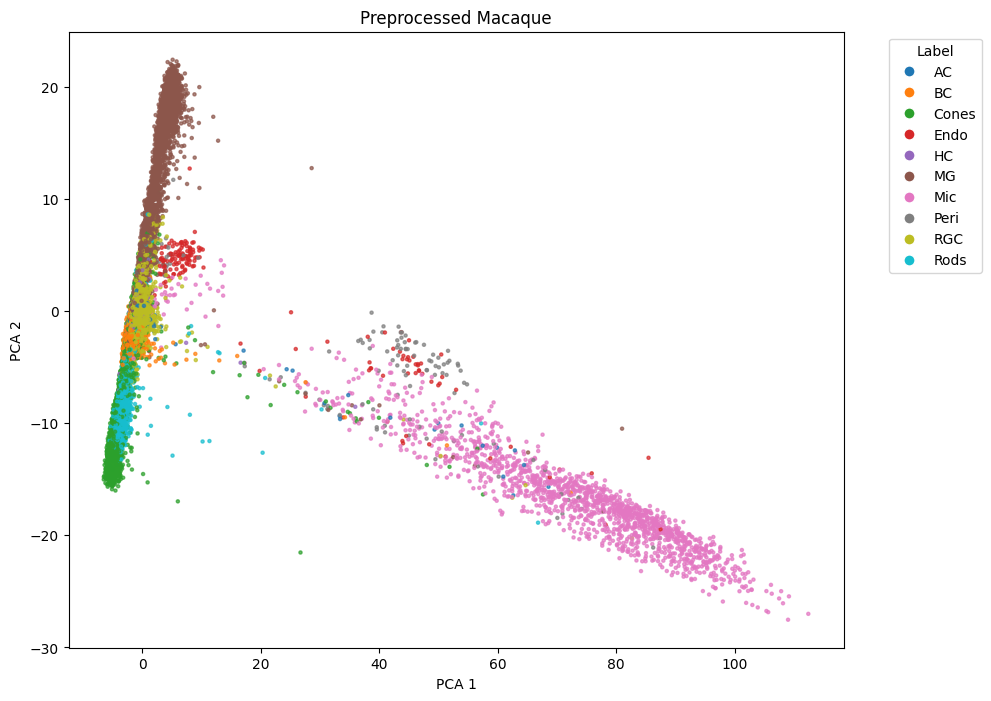

In [11]:
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X[:, 0], X[:, 1], c=pd.Categorical(y).codes, cmap='tab10', s=5, alpha=0.7)
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('Preprocessed Macaque')

handles = []
labels_unique = pd.Categorical(y).categories
for idx, label in enumerate(labels_unique):
    handles.append(plt.Line2D([], [], marker='o', color='w', markerfacecolor=scatter.cmap(idx), markersize=8, label=str(label)))
plt.legend(handles=handles, title='Label', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

---

### Get most stable pre-processing pipeline:

In [12]:
proportion = 0.1
size = int(X.shape[0] * proportion)

rng = np.random.default_rng(seed=0)

idx = rng.choice(X.shape[0], size=size, replace=False)

X_sub = X[idx]
y_sub = y[idx]

In [ ]:
# spectral clustering
# pairwise squared Euclidean distances
D2 = pairwise_distances(X_sub, metric='sqeuclidean')
median_d2 = np.median(D2[np.triu_indices_from(D2, k=1)])
gamma = 1.0 / (2.0 * median_d2) if median_d2 > 0 else 1.0

n_clusters = len(np.unique(y))

spectral = SpectralClustering(n_clusters=n_clusters, gamma=gamma, affinity='rbf', random_state=42, n_jobs=-1)
labels_pred = spectral.fit_predict(X_sub)

# get ARI
ari = adjusted_rand_score(pd.Categorical(y_sub).codes, labels_pred)
print("ARI:", ari)

ARI: 0.000284455758648833


/Users/kaiwycik/Documents/GitHub/ClusteringValidation/.venv/lib/python3.12/site-packages/sklearn/base.py:1365: ConvergenceWarning:

Number of distinct clusters (2) found smaller than n_clusters (10). Possibly due to duplicate points in X.



In [ ]:
# hierarchical clustering
n_clusters = len(np.unique(y))

hierarchical = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
labels_pred = hierarchical.fit_predict(X_sub)

# get ARI
ari = adjusted_rand_score(pd.Categorical(y_sub).codes, labels_pred)
print("ARI:", ari)

ARI: 0.2648953398761382


In [27]:
cfg1 = ValidatorConfig(
    X=X_sub,
    ref_labels=y_sub, 
    B=100,
    model_grids=[
        # (KMeans, {"n_clusters": [8, 9, 10, 11, 12]}),
        # (SpectralClustering, {"n_clusters": [8, 9, 10, 11, 12], 'gamma': [gamma]}),
        (AgglomerativeClustering, {"n_clusters": [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16], 'linkage': ['ward']})
    ]
)

val1 = CARVE(cfg1)
val1.validate(random_preprocess=False, random_state=42)

Grid configs:   0%|          | 0/15 [00:00<?, ?it/s]

In [28]:
val1.plot_results()

In [35]:
val1.plot_results()

In [18]:
# val1.plot_results_preprocessing()

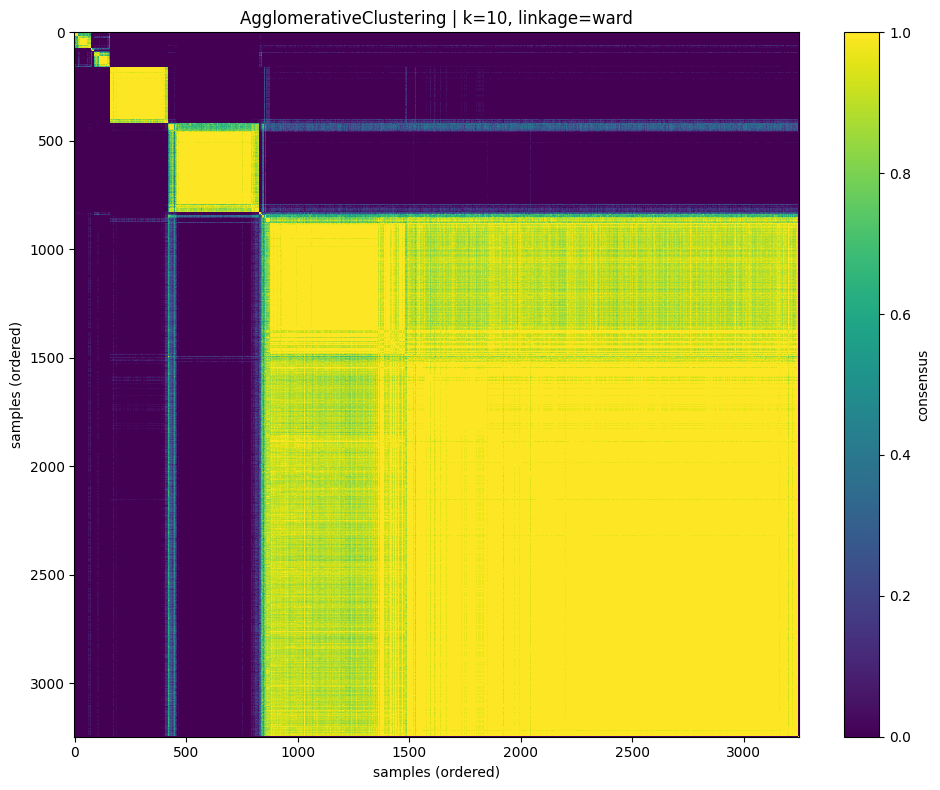

In [37]:
val1.plot_consensus_matrix(k=10)

/Users/kaiwycik/Documents/GitHub/ClusteringValidation/src/carve/_plotting.py:474: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



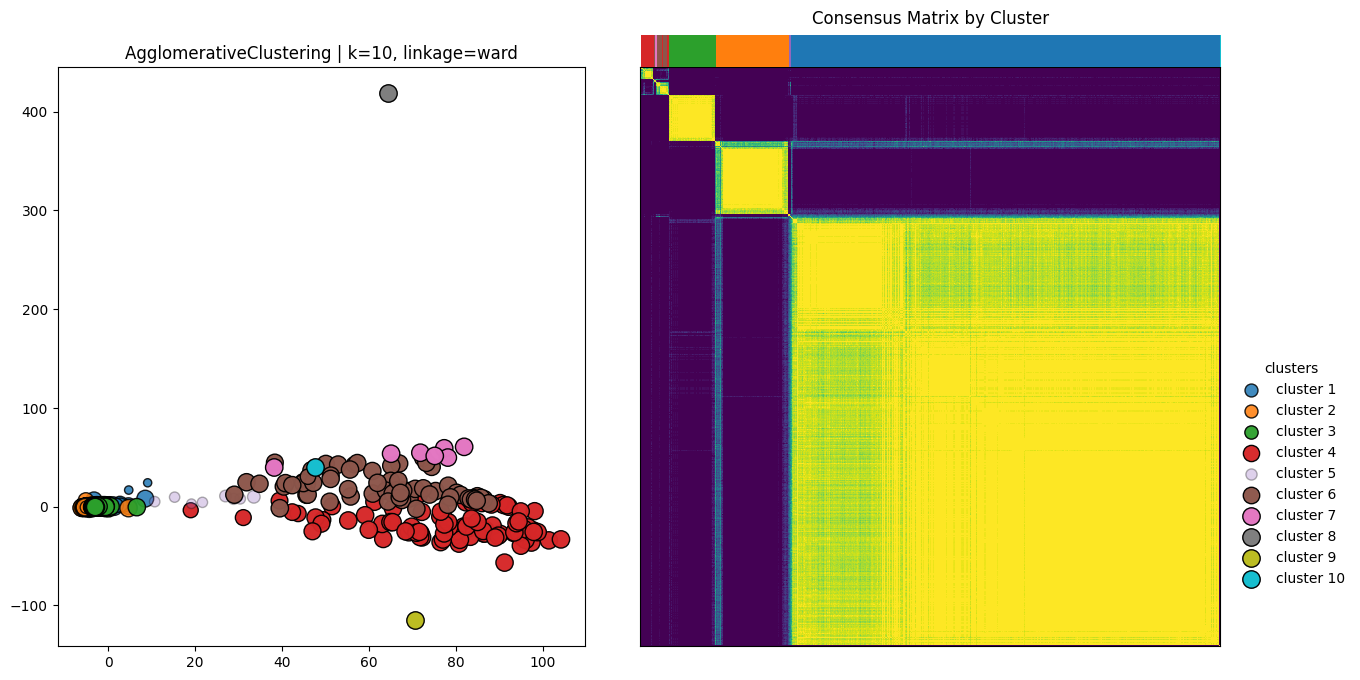

In [45]:
val1.plot_consensus_clustering(k=10, figsize=(15, 8))

In [36]:
val1.plot_clustering(k=2)

FigureWidget({
    'data': [{'customdata': {'bdata': ('AAAAAACASUAAAAAAAAAAAAAAAAAAAP' ... 'rZ26Hk7z8XJyoFj+DvPwAAAAAAAPA/'),
                             'dtype': 'f8',
                             'shape': '163, 6'},
              'hovertemplate': ('sample %{customdata[0]}<br>clu' ... 'tomdata[5]:.4f}<extra></extra>'),
              'legendgroup': 'cluster-0',
              'marker': {'color': '#636EFA',
                         'line': {'color': 'black', 'width': 1.0},
                         'opacity': 0.3,
                         'size': {'bdata': ('tD3u24zRKkBw1yEG6dAqQFQGgZDU0S' ... 'fx4hwpQKjYgk2bhyZAUlb3smvRKkA='),
                                  'dtype': 'f8'}},
              'mode': 'markers',
              'name': 'cluster 1',
              'showlegend': True,
              'type': 'scatter',
              'uid': 'ca264002-2239-424e-9e33-26952a30f004',
              'x': {'bdata': ('RQd7Bbe8VECfIWA+KgZXQHRRYxq/91' ... 'Q3W7pDQKq6G+TA9jJAtF+ABO14UkA='),
                 

In [31]:
val1.plot_clustering(k=10)

FigureWidget({
    'data': [{'customdata': {'bdata': ('AAAAAACASUAAAAAAAAAAAAAAAAAAAP' ... 'dYjbPZ5z84LctGNEPlP5qZmZmZmdk/'),
                             'dtype': 'f8',
                             'shape': '88, 6'},
              'hovertemplate': ('sample %{customdata[0]}<br>clu' ... 'tomdata[5]:.4f}<extra></extra>'),
              'legendgroup': 'cluster-0',
              'marker': {'color': '#636EFA',
                         'line': {'color': 'black', 'width': 1.0},
                         'opacity': 0.971389906098201,
                         'size': {'bdata': ('hWFmgkO2KkC3mbBg5qEqQHWb+mUouC' ... 'DEoZ0qQEdcD9n9iipA+5HYizEGJ0A='),
                                  'dtype': 'f8'}},
              'mode': 'markers',
              'name': 'cluster 1',
              'showlegend': True,
              'type': 'scatter',
              'uid': '4dfff253-aa1e-4d6b-b402-935a3417ec4d',
              'x': {'bdata': ('RQd7Bbe8VECfIWA+KgZXQHRRYxq/91' ... 'TanxdRQDnxs24EmFdAqrob5MD2MkA='),
    

In [32]:
val1.plot_clustering(k=15)

FigureWidget({
    'data': [{'customdata': {'bdata': ('AAAAAAAgZkAAAAAAAAAAAAAAAAAAAP' ... '1kCIBY7z8VmOfZzE/vP9u2bdu2bds/'),
                             'dtype': 'f8',
                             'shape': '25, 6'},
              'hovertemplate': ('sample %{customdata[0]}<br>clu' ... 'tomdata[5]:.4f}<extra></extra>'),
              'legendgroup': 'cluster-0',
              'marker': {'color': '#636EFA',
                         'line': {'color': 'black', 'width': 1.0},
                         'opacity': 0.9252574616597484,
                         'size': {'bdata': ('7sPNMzbCKkDZTcL4R7sqQFPMFm1Cyy' ... 'AFCZYqQGL+1PPGpypA+YAfIUGAKkA='),
                                  'dtype': 'f8'}},
              'mode': 'markers',
              'name': 'cluster 1',
              'showlegend': True,
              'type': 'scatter',
              'uid': 'b14fb335-dc38-474d-b9cd-caf2bddcaf37',
              'x': {'bdata': ('IBJsDDAbUkD9p0SRfJhSQOKi6CiCuV' ... 'dLmpFJQG/msLQd9kZABMydm/MnRUA='),
   